In this assignment, you are required to implement functions to calculate the listed performance measures below from scratch. **YOU CAN USE NUMPY FOR CALCULATIONS AND MATPLOTLIB FOR VISUALIZATION. DON'T USE ANY OTHER PACKAGE**.

* Accuracy
* Confusion matrix
* Percision
* Recall
* F1 score
* AUC of ROC


You're also required to implement functions to display the following
* Confusion matrix
* Percision VS Recall curve
* ROC curve

After finishing the assignment, please run all cells then save the notebook as PDF and attach the PDF to the original notebook in the email.

In [4]:
# DON'T CHANGE THIS
# DON'T 
import numpy as np
import matplotlib.pyplot as np

np.random.seed(42)

y = np.random.randint(2, size=(100, 1))          # Generating random labels
y_preds = np.random.uniform(0, 1, size=(100, 1)) # Generating random predictions


AttributeError: module 'matplotlib.pyplot' has no attribute 'random'

In [5]:
# DON'T CHANGE THIS
import matplotlib.pyplot as plt

plt.plot(y)
plt.plot(y_preds)

NameError: name 'y' is not defined

In [6]:
# DON'T CHANGE THIS
# DON'T 
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

y = np.random.randint(2, size=(100, 1))          # Generating random labels
y_preds = np.random.uniform(0, 1, size=(100, 1)) # Generating random predictions


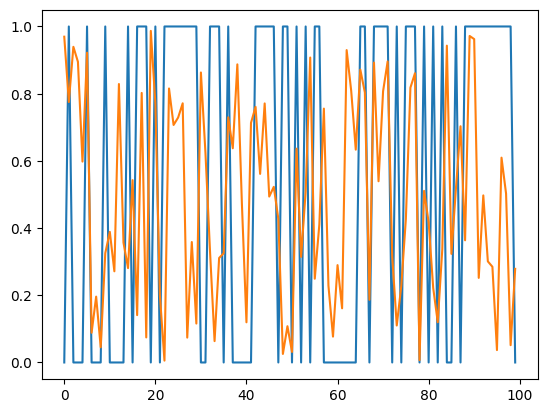

In [7]:
# DON'T CHANGE THIS
import matplotlib.pyplot as plt

plt.plot(y)
plt.plot(y_preds)

You can start your implementation below.

In [8]:
def confusion_matrix(true,pred):
  classes = set(true + pred)
  num_classes = len(classes)
  shape = (num_classes, num_classes)
  mat = np.zeros(shape)
  n = max(len(true),len(pred))
  for i in range(num_classes):
    for j in range(num_classes):
      for k in range(n):
        if true[k]-1 == i:
          if pred[k]-1 == j:
            mat[i][j] = mat[i][j] + 1
  return mat

def TP(true, pred):
  tp = 0
  for truth, pred in zip(true, pred):
    if truth == 1 and pred == 1:
      tp += 1
  return tp

def TN(true, pred):
  tn = 0
  for truth, pred in zip(true, pred):
    if truth == 0 and pred == 0:
      tn += 1
  return tn

def FP(true, pred):
  fp = 0
  for truth, pred in zip(true, pred):
    if truth == 0 and pred == 1:
      fp += 1
  return fp

def FN(true, pred):
  fn = 0
  for truth, pred in zip(true, pred):
    if truth == 1 and pred == 0:
      fn += 1
  return fn

def accuracy(true, pred):
    tp = TP(true, pred)
    tn = TN(true, pred)
    fp = FP(true, pred)
    fn = FN(true, pred)
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) != 0 else 0
    return accuracy

def precision(true, pred):
    tp = TP(true, pred)
    fp = FP(true, pred)
    precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    return precision

def recall(true, pred):
    tp = TP(true, pred)
    fn = FN(true, pred)
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0
    return recall

def f1_score(true, pred):
    prec = precision(true, pred)
    rec = recall(true, pred)
    f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) != 0 else 0
    return f1

def perf_matrix(y_actual, y_hat,threshold):
    tp = 0
    fp = 0
    tn = 0
    fn = 0    
    for i in range(len(y_hat)): 
        if(y_hat[i] >= threshold):
            if(y_actual[i] == 1):
                tp += 1
            else:
                fp += 1
        elif(y_hat[i] < threshold):
            if(y_actual[i] == 0):
                tn += 1
            else:
                fn += 1
    tpr = tp/(tp+fn) if (tp+fn) != 0 else 0
    fpr = fp/(fp+tn) if (fp+tn) != 0 else 0
    auc = np.trapezoid([0, fpr, 1], [0, tpr, 1])
    return [fpr,tpr], auc

def plot_ROC(y_actual, y_pred, thresholds):
    roc_points = []
    for threshold in thresholds:
        points, auc = perf_matrix(y_actual, y_pred, threshold)
        roc_points.append(points)
    roc_points = np.array(roc_points)
    sorted_indices = np.argsort(roc_points[:, 0])
    roc_points = roc_points[sorted_indices]
    plt.plot(roc_points[:,0], roc_points[:,1])
    plt.plot([0, 1], [0, 1], 'k--', linewidth=2)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.show()


def precision_recall_curve(y_true, y_pred, thresholds):
    pr_points = []
    for threshold in thresholds:
        y_pred_thresholded = [1 if p >= threshold else 0 for p in y_pred]
        prec = precision(y_true, y_pred_thresholded)
        rec = recall(y_true, y_pred_thresholded)
        pr_points.append([rec, prec])
    pr_points = np.array(pr_points)
    sorted_indices = np.argsort(pr_points[:, 0])
    pr_points = pr_points[sorted_indices]
    plt.plot(pr_points[:,0], pr_points[:,1])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.show()

Confusion Matrix:
[[29.  0.]
 [ 0.  0.]]
TN: 29.0
FP: 0.0
FN: 0.0
TP: 0.0
Accuracy: 0.5400
Precision: 0.6042
Recall: 0.5179
F1 Score: 0.5577


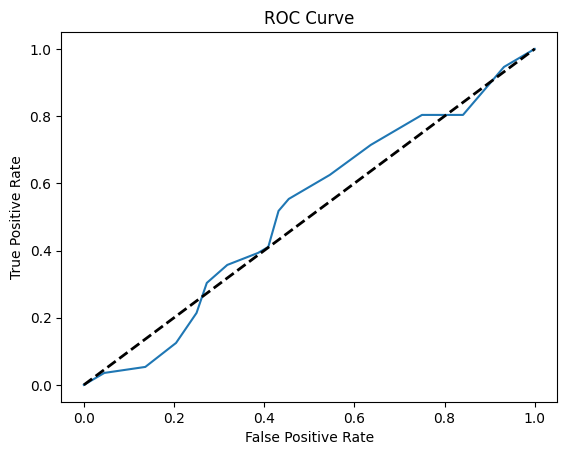

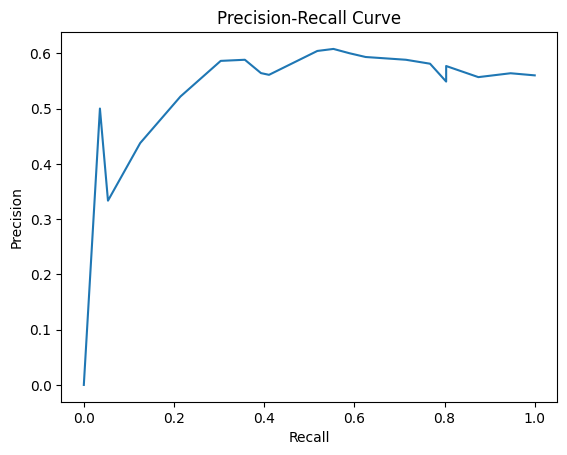

True Positives (TP): 29
True Negatives (TN): 25
False Positives (FP): 19
False Negatives (FN): 27
Total Samples: 100


In [9]:
y_flat = y.flatten().tolist()
y_preds_flat = y_preds.flatten().tolist()
y_preds_binary = (y_preds >= 0.5).flatten().astype(int).tolist()

cm = confusion_matrix(y_flat, y_preds_binary)
print("Confusion Matrix:")
print(cm)
print(f"TN: {(cm[0][0])}")
print(f"FP: {(cm[0][1])}")
print(f"FN: {(cm[1][0])}")
print(f"TP: {(cm[1][1])}")

acc = accuracy(y_flat, y_preds_binary)
print(f"Accuracy: {acc:.4f}")

prec = precision(y_flat, y_preds_binary)
print(f"Precision: {prec:.4f}")

rec = recall(y_flat, y_preds_binary)
print(f"Recall: {rec:.4f}")

f1 = f1_score(y_flat, y_preds_binary)
print(f"F1 Score: {f1:.4f}")


thresholds_roc = np.arange(0, 1.05, 0.05)
plot_ROC(y_flat, y_preds_flat, thresholds_roc)

thresholds_pr = np.arange(0, 1.05, 0.05)
precision_recall_curve(y_flat, y_preds_flat, thresholds_pr)

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_thresh = [1 if p >= threshold else 0 for p in y_preds_flat]
    acc_t = accuracy(y_flat, y_pred_thresh)
    prec_t = precision(y_flat, y_pred_thresh)
    rec_t = recall(y_flat, y_pred_thresh)
    f1_t = f1_score(y_flat, y_pred_thresh)
    
tp = TP(y_flat, y_preds_binary)
tn = TN(y_flat, y_preds_binary)
fp = FP(y_flat, y_preds_binary)
fn = FN(y_flat, y_preds_binary)
print(f"True Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"Total Samples: {tp + tn + fp + fn}")